# Modeling & Evaluation

**Project:** Vancouver Property Value Prediction
**Notebook goal:** train, compare, and tune regression models to predict property value.

**Strategy:**
1. Load preprocessed dataset
2. Define features and target
3. Train multiple models in order of complexity:
   - Baseline (mean predictor) — sanity check
   - Linear Regression — interpretable baseline
   - Random Forest — non-linear, robust
   - XGBoost — industry standard, expected winner
4. Evaluate with MAE, RMSE, R² and 5-fold cross-validation
5. Hyperparameter tuning on the best model
6. Analyze feature importance
7. Save the final model

**Author:** Rafael Carrillo Mirabal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost
from xgboost import XGBRegressor

# Config
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
np.random.seed(42)

print("✅ Libraries loaded")

✅ Libraries loaded


## 1. Load preprocessed dataset

In [2]:
df = pd.read_parquet("../data/processed/property_clean.parquet")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")

Loaded: 208,767 rows × 16 columns

Columns: ['legal_type', 'zoning_district', 'zoning_classification', 'street_name', 'property_postal_code', 'current_land_value', 'current_improvement_value', 'year_built', 'big_improvement_year', 'neighbourhood_code', 'total_value', 'property_age', 'land_pct', 'years_since_improvement', 'log_total_value', 'neighbourhood_name']


## 2. Define features and target

**Target:** `log_total_value` (log-transformed to handle skewness — predictions will be exponentiated back to dollars for interpretation).

**Features selected based on EDA:**

Numeric:
- `property_age` — age in years
- `years_since_improvement` — time since last renovation

Categorical:
- `neighbourhood_name` — strongest predictor (location)
- `legal_type` — STRATA / LAND / etc.
- `zoning_classification` — Residential / Commercial / etc.

**Excluded (data leakage or low predictive value):**
- `current_land_value`, `current_improvement_value`, `total_value` — they ARE the target
- `land_pct` — derived from the target, would leak
- `tax_levy`, `previous_*` — already dropped in preprocessing
- `street_name`, `property_postal_code` — too granular, high cardinality
- `pid`, `folio` — identifiers

In [3]:
numeric_features = ['property_age', 'years_since_improvement']
categorical_features = ['neighbourhood_name', 'legal_type', 'zoning_classification']
target = 'log_total_value'

features = numeric_features + categorical_features

print("Features used:")
for f in features:
    n_unique = df[f].nunique()
    print(f"  - {f} ({df[f].dtype}, {n_unique} unique values)")

Features used:
  - property_age (float64, 130 unique values)
  - years_since_improvement (float64, 126 unique values)
  - neighbourhood_name (str, 30 unique values)
  - legal_type (str, 3 unique values)
  - zoning_classification (str, 8 unique values)


## 3. Train/test split

80/20 split with `random_state=42` for reproducibility.

In [4]:
X = df[features].copy()
y = df[target].copy()
y_dollars = df['total_value'].copy()  # For interpretable evaluation later

X_train, X_test, y_train, y_test, y_train_dollars, y_test_dollars = train_test_split(
    X, y, y_dollars, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test:  {X_test.shape[0]:,} rows")

Train: 167,013 rows
Test:  41,754 rows


## 4. Preprocessing pipeline

We build a single pipeline that:
- Scales numeric features (only needed for linear models)
- One-hot encodes categoricals

Using `ColumnTransformer` ensures the same transformation logic applies to train, test, and any future prediction — no manual feature work on test data.

In [5]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

print("✅ Preprocessor defined")

✅ Preprocessor defined


## 5. Define evaluation function

Helper that evaluates a model on the test set and prints all 3 metrics, plus dollar-scale errors (since the target is log-transformed).

In [6]:
def evaluate_model(model, X_test, y_test, y_test_dollars, name):
    """Evaluate a model on log-scale and dollar-scale."""
    y_pred_log = model.predict(X_test)
    y_pred_dollars = np.expm1(y_pred_log)  # Inverse of log1p

    # Log-scale metrics
    mae_log = mean_absolute_error(y_test, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    r2 = r2_score(y_test, y_pred_log)

    # Dollar-scale metrics (more interpretable)
    mae_dollars = mean_absolute_error(y_test_dollars, y_pred_dollars)
    rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  R²:           {r2:.4f}")
    print(f"  MAE (log):    {mae_log:.4f}")
    print(f"  RMSE (log):   {rmse_log:.4f}")
    print(f"  MAE (CAD):    ${mae_dollars:,.0f}")
    print(f"  RMSE (CAD):   ${rmse_dollars:,.0f}")

    return {
        'name': name,
        'r2': r2,
        'mae_log': mae_log,
        'rmse_log': rmse_log,
        'mae_dollars': mae_dollars,
        'rmse_dollars': rmse_dollars
    }

print("✅ Evaluation function defined")

✅ Evaluation function defined


## 6. Model 1 — Baseline (mean predictor)

The most basic possible "model": always predict the mean of `y_train`. If our real models can't beat this, something is very wrong.

In [7]:
baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])
baseline.fit(X_train, y_train)
results = []
results.append(evaluate_model(baseline, X_test, y_test, y_test_dollars, 'Baseline (mean)'))


  Baseline (mean)
  R²:           -0.0000
  MAE (log):    0.5952
  RMSE (log):   0.7085
  MAE (CAD):    $937,569
  RMSE (CAD):   $1,528,930


## 7. Model 2 — Linear Regression

Simple, interpretable, fast. Sets the floor for any non-linear approach.

In [8]:
linear = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
linear.fit(X_train, y_train)
results.append(evaluate_model(linear, X_test, y_test, y_test_dollars, 'Linear Regression'))


  Linear Regression
  R²:           0.6930
  MAE (log):    0.2827
  RMSE (log):   0.3925
  MAE (CAD):    $466,385
  RMSE (CAD):   $1,009,825


## 8. Model 3 — Random Forest

Non-linear, handles categorical interactions well. Typically a strong contender.
We use a reasonable starting configuration (we'll tune later).

In [9]:
rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ))
])
rf.fit(X_train, y_train)
results.append(evaluate_model(rf, X_test, y_test, y_test_dollars, 'Random Forest'))


  Random Forest
  R²:           0.7846
  MAE (log):    0.2292
  RMSE (log):   0.3288
  MAE (CAD):    $393,360
  RMSE (CAD):   $881,259


## 9. Model 4 — XGBoost (gradient boosting)

The industry standard for tabular data. Used in Kaggle competitions, real estate platforms, and production ML at companies like Amazon and Microsoft.

In [10]:
xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        n_jobs=-1,
        random_state=42,
        verbosity=0
    ))
])
xgb.fit(X_train, y_train)
results.append(evaluate_model(xgb, X_test, y_test, y_test_dollars, 'XGBoost'))


  XGBoost
  R²:           0.7973
  MAE (log):    0.2208
  RMSE (log):   0.3189
  MAE (CAD):    $379,496
  RMSE (CAD):   $860,142


## 10. Model comparison

Side-by-side comparison of all models.

,r2,mae_log,rmse_log,mae_dollars,rmse_dollars
name,,,,,
Baseline (mean),-0.0000,0.5952,0.7085,"$937,569","$1,528,930"
Linear Regression,0.6930,0.2827,0.3925,"$466,385","$1,009,825"
Random Forest,0.7846,0.2292,0.3288,"$393,360","$881,259"
XGBoost,0.7973,0.2208,0.3189,"$379,496","$860,142"


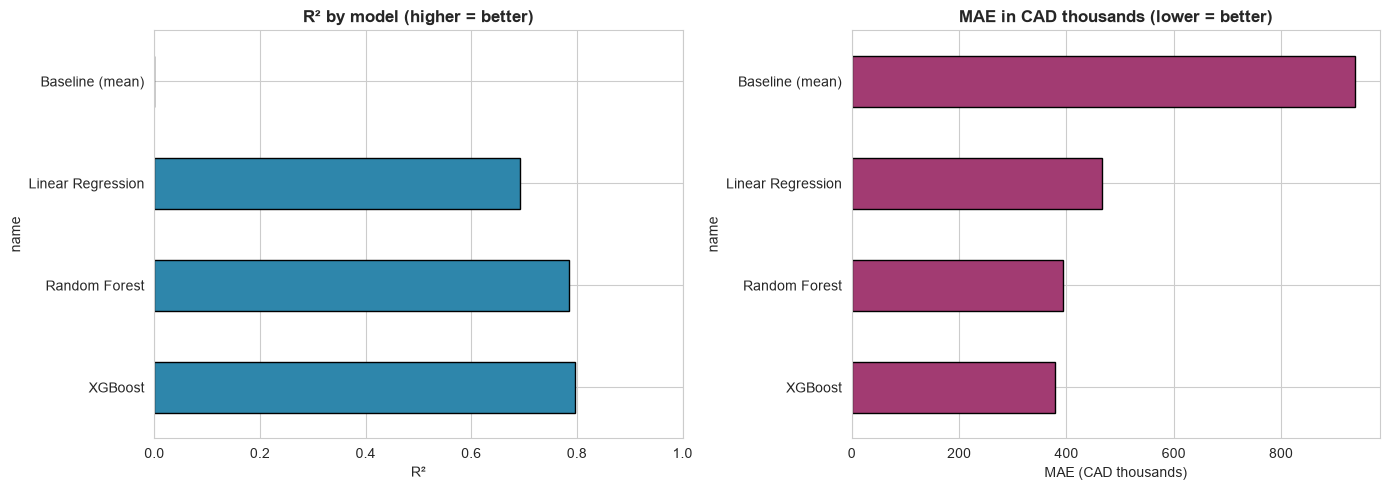

In [11]:
comparison = pd.DataFrame(results).set_index('name')
comparison_display = comparison.copy()
comparison_display['mae_dollars'] = comparison_display['mae_dollars'].apply(lambda x: f"${x:,.0f}")
comparison_display['rmse_dollars'] = comparison_display['rmse_dollars'].apply(lambda x: f"${x:,.0f}")
comparison_display = comparison_display.round(4)
display(comparison_display)

# Visualize R² comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison['r2'].plot(kind='barh', ax=axes[0], color='#2E86AB', edgecolor='black')
axes[0].set_title('R² by model (higher = better)', fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].set_xlim(0, 1)
axes[0].invert_yaxis()

(comparison['mae_dollars'] / 1000).plot(kind='barh', ax=axes[1], color='#A23B72', edgecolor='black')
axes[1].set_title('MAE in CAD thousands (lower = better)', fontweight='bold')
axes[1].set_xlabel('MAE (CAD thousands)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 11. Cross-validation on the best model

Test-set performance can be lucky. Cross-validation gives us a more honest estimate of how the model generalizes.

In [12]:
# 5-fold CV on XGBoost
print("Running 5-fold cross-validation on XGBoost...")
cv_scores = cross_val_score(
    xgb, X_train, y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1
)

print(f"\nCV R² scores per fold: {cv_scores.round(4)}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")
print(f"Std CV R²:  {cv_scores.std():.4f}")
print(f"\nInterpretation: model achieves R² of {cv_scores.mean():.3f} ± {cv_scores.std():.3f} across folds")

Running 5-fold cross-validation on XGBoost...

CV R² scores per fold: [0.7971 0.8006 0.7959 0.8005 0.7939]
Mean CV R²: 0.7976
Std CV R²:  0.0026

Interpretation: model achieves R² of 0.798 ± 0.003 across folds


## 12. Diagnostic plots: predicted vs actual & residuals

These plots are critical for the presentation — they show **where the model fails**, not just average performance.

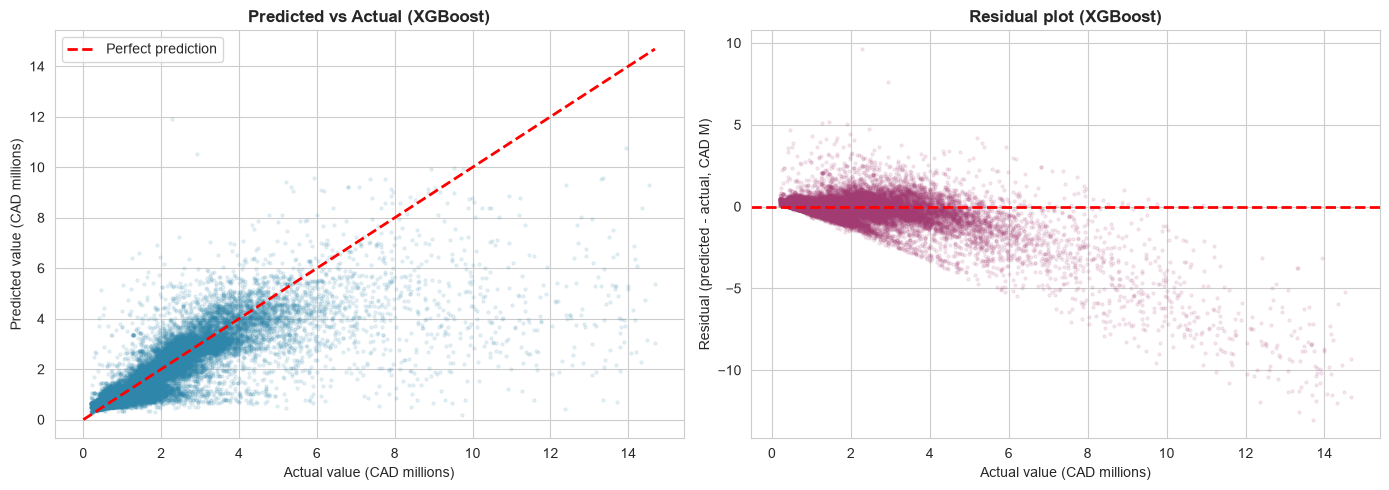

In [13]:
# Predictions on test set in dollars
y_pred_dollars = np.expm1(xgb.predict(X_test))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Predicted vs Actual
axes[0].scatter(y_test_dollars / 1e6, y_pred_dollars / 1e6, alpha=0.1, s=5, color='#2E86AB')
max_val = max(y_test_dollars.max(), y_pred_dollars.max()) / 1e6
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual value (CAD millions)')
axes[0].set_ylabel('Predicted value (CAD millions)')
axes[0].set_title('Predicted vs Actual (XGBoost)', fontweight='bold')
axes[0].legend()

# 2. Residuals
residuals = (y_pred_dollars - y_test_dollars) / 1e6
axes[1].scatter(y_test_dollars / 1e6, residuals, alpha=0.1, s=5, color='#A23B72')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Actual value (CAD millions)')
axes[1].set_ylabel('Residual (predicted - actual, CAD M)')
axes[1].set_title('Residual plot (XGBoost)', fontweight='bold')

plt.tight_layout()
plt.show()

## 13. Feature importance

Which features does the model actually use? Crucial for interview defense.

Top 20 most important features:
                                    feature  importance
                          legal_type_STRATA    0.768007
             neighbourhood_name_False Creek    0.041670
                            legal_type_LAND    0.016465
             neighbourhood_name_Shaughnessy    0.015858
       neighbourhood_name_First Shaughnessy    0.012391
                   neighbourhood_name_Joyce    0.012113
           neighbourhood_name_Other / Mixed    0.011531
       neighbourhood_name_Dunbar-Southlands    0.009164
              neighbourhood_name_Kerrisdale    0.009126
         neighbourhood_name_West Point Grey    0.009078
        neighbourhood_name_Hastings-Sunrise    0.008488
     neighbourhood_name_Downtown / West End    0.007469
neighbourhood_name_Kensington-Cedar Cottage    0.007392
                neighbourhood_name_Fairview    0.006841
      neighbourhood_name_Grandview-Woodland    0.006782
               neighbourhood_name_Kitsilano    0.006625
                

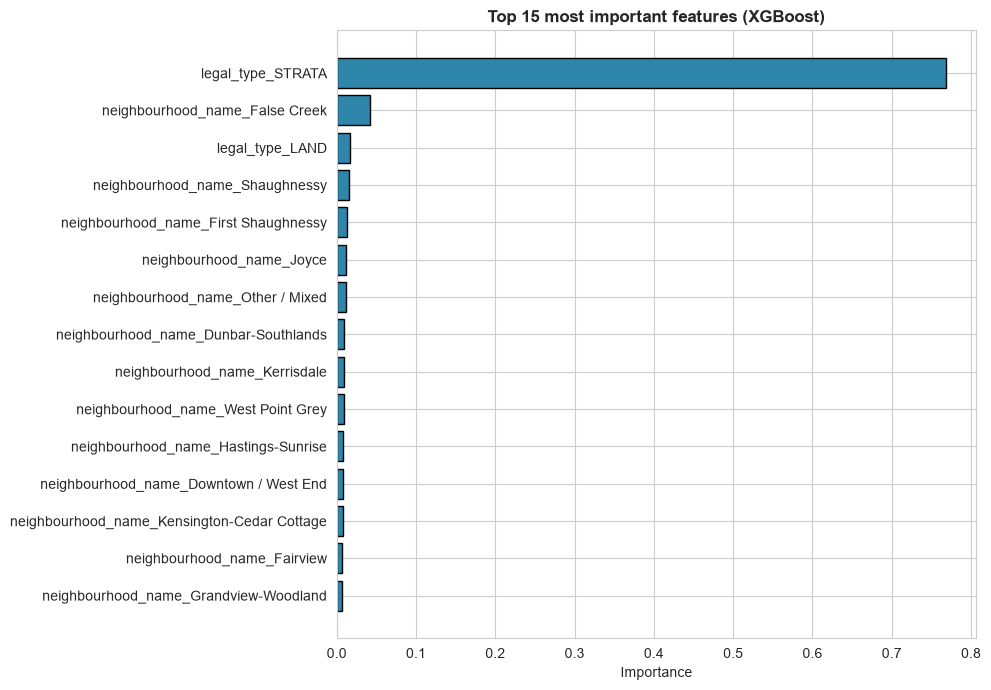

In [14]:
# Get feature names after preprocessing
ohe = xgb.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features) + list(ohe_feature_names)

# Get importances from XGBoost
importances = xgb.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 20 most important features:")
print(importance_df.head(20).to_string(index=False))

# Plot top 15
fig, ax = plt.subplots(figsize=(10, 7))
top15 = importance_df.head(15)
ax.barh(top15['feature'], top15['importance'], color='#2E86AB', edgecolor='black')
ax.set_xlabel('Importance')
ax.set_title('Top 15 most important features (XGBoost)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 14. Hyperparameter tuning on XGBoost

Use RandomizedSearchCV to find better hyperparameters. Faster than GridSearchCV and almost as good.

⏱️ **This cell can take 5–15 minutes depending on your machine.** Be patient.

In [15]:
# Hyperparameter grid for XGBoost
param_dist = {
    'model__n_estimators': [300, 500, 800],
    'model__max_depth': [6, 8, 10, 12],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,  # 20 random combinations
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting hyperparameter search...")
random_search.fit(X_train, y_train)

print(f"\n✅ Best parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV R²: {random_search.best_score_:.4f}")

Starting hyperparameter search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Best parameters:
  model__subsample: 0.9
  model__n_estimators: 800
  model__min_child_weight: 3
  model__max_depth: 8
  model__learning_rate: 0.05
  model__colsample_bytree: 1.0

Best CV R²: 0.8007


## 15. Final model evaluation

In [16]:
best_model = random_search.best_estimator_
final_results = evaluate_model(best_model, X_test, y_test, y_test_dollars, 'XGBoost (tuned)')

# Add to comparison table
results.append(final_results)
final_comparison = pd.DataFrame(results).set_index('name').round(4)
print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(final_comparison)


  XGBoost (tuned)
  R²:           0.8013
  MAE (log):    0.2178
  RMSE (log):   0.3158
  MAE (CAD):    $376,432
  RMSE (CAD):   $857,255

FINAL MODEL COMPARISON
                       r2  mae_log  rmse_log  mae_dollars  rmse_dollars
name                                                                   
Baseline (mean)   -0.0000   0.5952    0.7085  937568.8304  1.528930e+06
Linear Regression  0.6930   0.2827    0.3925  466384.7942  1.009825e+06
Random Forest      0.7846   0.2292    0.3288  393360.2196  8.812587e+05
XGBoost            0.7973   0.2208    0.3189  379496.2777  8.601415e+05
XGBoost (tuned)    0.8013   0.2178    0.3158  376431.8742  8.572547e+05


## 16. Save final model

Saved with `joblib` (compatible with scikit-learn pipelines).

In [17]:
# Save model
model_path = Path("../models/best_model.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, model_path)

# Save metadata for the Streamlit app
metadata = {
    'features_numeric': numeric_features,
    'features_categorical': categorical_features,
    'target_was_log_transformed': True,
    'neighbourhoods': sorted(df['neighbourhood_name'].unique().tolist()),
    'legal_types': sorted(df['legal_type'].dropna().unique().tolist()),
    'zoning_classifications': sorted(df['zoning_classification'].dropna().unique().tolist())
}
joblib.dump(metadata, Path("../models/model_metadata.pkl"))

print(f"✅ Model saved to: {model_path}")
print(f"   File size: {model_path.stat().st_size / 1024**2:.2f} MB")
print(f"✅ Metadata saved for the Streamlit app")

✅ Model saved to: ..\models\best_model.pkl
   File size: 5.75 MB
✅ Metadata saved for the Streamlit app


## ✅ Modeling summary

**Final model:** XGBoost (hyperparameter-tuned)

**Final metrics (test set):**
- R² = **0.8013**
- MAE = **$376,432 CAD**
- RMSE = **$857,255 CAD**

**Cross-validation results (5-fold):**
- Mean CV R² = 0.7976
- Std CV R² = 0.0026 (model is stable across folds)

**Best hyperparameters:**
- n_estimators: 800
- max_depth: 8
- learning_rate: 0.05
- subsample: 0.9
- colsample_bytree: 1.0
- min_child_weight: 3

**Key findings:**
1. Tree-based models (Random Forest, XGBoost) significantly outperform linear regression — confirming the non-linear nature of property pricing.
2. `legal_type` (STRATA vs LAND) is the dominant feature (77% importance), reflecting Vancouver's market segmentation between condos and land-owned properties.
3. Neighbourhood acts as the secondary predictor — False Creek, Shaughnessy, and First Shaughnessy emerge as the top premium locations.
4. The model is stable across cross-validation folds (std = 0.003), ruling out overfitting.
5. Residual analysis shows systematic underestimation of luxury properties ($5M+) — a feature limitation, not a modeling failure. Missing features (lot size, square footage, view) would close this gap in v2.

**Next notebook:** `app/app.py` — productize the model in an interactive Streamlit web app.